# Phase 3: nothing is independent

Three layers, each building on the last (`docs/decisions/0003`, `0007`; `docs/math.md` 5-6):

1. **Pairwise dependence.** For every cross-group pair (fiscal x rates x macro x labor): full-sample and rolling
   correlation, lead/lag scan, Granger causality both ways with Benjamini-Hochberg control. A wide rolling range means
   one number misdescribes the pair.
2. **Block factors.** Highly correlated series act as one: each behavioral block (consumer, corporate, financial
   conditions, fiscal, labor, rates, prices) is reduced to a single interpretable factor. The residual of each series
   against its factor is the imperfect-correlation shock.
3. **Latent states.** A Markov chain on the factor vector, estimated as a hidden Markov model, with within-state
   dynamics and bootstrapped residuals. Outcomes become mixtures over states, not normals.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
import bond_sim.notebook as nb
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
plt.rcParams["figure.dpi"] = 110

# ── parameters: change and rerun ─────────────────────────────────────────────
AS_OF = pd.Timestamp("2026-09-15")     # every loader filters on this date (point-in-time contract)
K = 1000                                 # Monte Carlo paths (raise for the paper)
FORCE_REFRESH = False                  # True re-downloads every series and rebuilds cached steps
os.environ["BOND_SIM_CACHE"] = "0" if FORCE_REFRESH else "1"
import bond_sim.config as bcfg
CFG_HASH = bcfg.load().content_hash()   # every cached step is keyed by the configuration that produced it
ctx = nb.cached(f"ctx_{AS_OF.date()}_{CFG_HASH}", lambda: nb.load_context(AS_OF), refresh=FORCE_REFRESH)
print(ctx.grid, "| config hash", CFG_HASH, "| series:", ctx.w.shape[1])

MonthlyGrid(1980-01-01 .. 2056-09-01, M=921) | config hash d9222bd624fd | series: 48


## 3.1 Pairwise dependence on the thesis pairs

In [2]:
from bond_sim.analysis import CorrelationAnalyzer, RegimeDetector
from bond_sim.cli import THESIS_GROUPS, _quarterly_panel
ids = [s for g in THESIS_GROUPS.values() for s in g]
group_of = {s: g for g, ss in THESIS_GROUPS.items() for s in ss}
wq = _quarterly_panel(ctx.w[[c for c in ids if c in ctx.w.columns]], ids)
an = CorrelationAnalyzer(wq, ctx.cfg.correlation, freq="Q")
rep = nb.cached(f"corr_report_{AS_OF.date()}_{CFG_HASH}", lambda: an.report(with_granger=True, group_of=group_of), refresh=FORCE_REFRESH)
display(rep.head(15)[["a", "b", "n", "full_corr", "rolling_min", "rolling_max", "best_lag", "leads", "granger_a_to_b_sig", "granger_b_to_a_sig"]].round(3))
print(f"{len(rep)} cross-group pairs; regime-dependent (rolling range > 0.5): {int(rep.regime_dependent.sum())}")

,a,b,n,full_corr,rolling_min,rolling_max,best_lag,leads,granger_a_to_b_sig,granger_b_to_a_sig
0,FDHBFRBN,ICSA,184,0.399,-0.776,0.962,0,None,True,True
1,FDHBFRBN,DGS3MO,178,-0.127,-0.832,0.809,8,FDHBFRBN,False,False
2,DGS3MO,CES5552200001,146,0.030,-0.756,0.835,-4,CES5552200001,False,False
3,FDHBFRBN,GDP,184,-0.320,-0.828,0.763,0,None,True,True
4,CPIAUCSL,UNRATE,186,-0.305,-0.879,0.688,0,None,False,False
5,A091RC1Q027SBEA,USCONS,185,0.265,-0.736,0.814,0,None,False,False
6,FDHBFRBN,UNRATE,184,0.367,-0.802,0.747,0,None,True,True
7,A091RC1Q027SBEA,CES5552200001,145,-0.209,-0.871,0.651,1,A091RC1Q027SBEA,False,False
8,FYGFGDQ188S,CPIAUCSL,184,-0.352,-0.863,0.637,0,None,False,False
9,A091RC1Q027SBEA,CES5553000001,145,0.288,-0.749,0.743,0,None,False,False


111 cross-group pairs; regime-dependent (rolling range > 0.5): 111


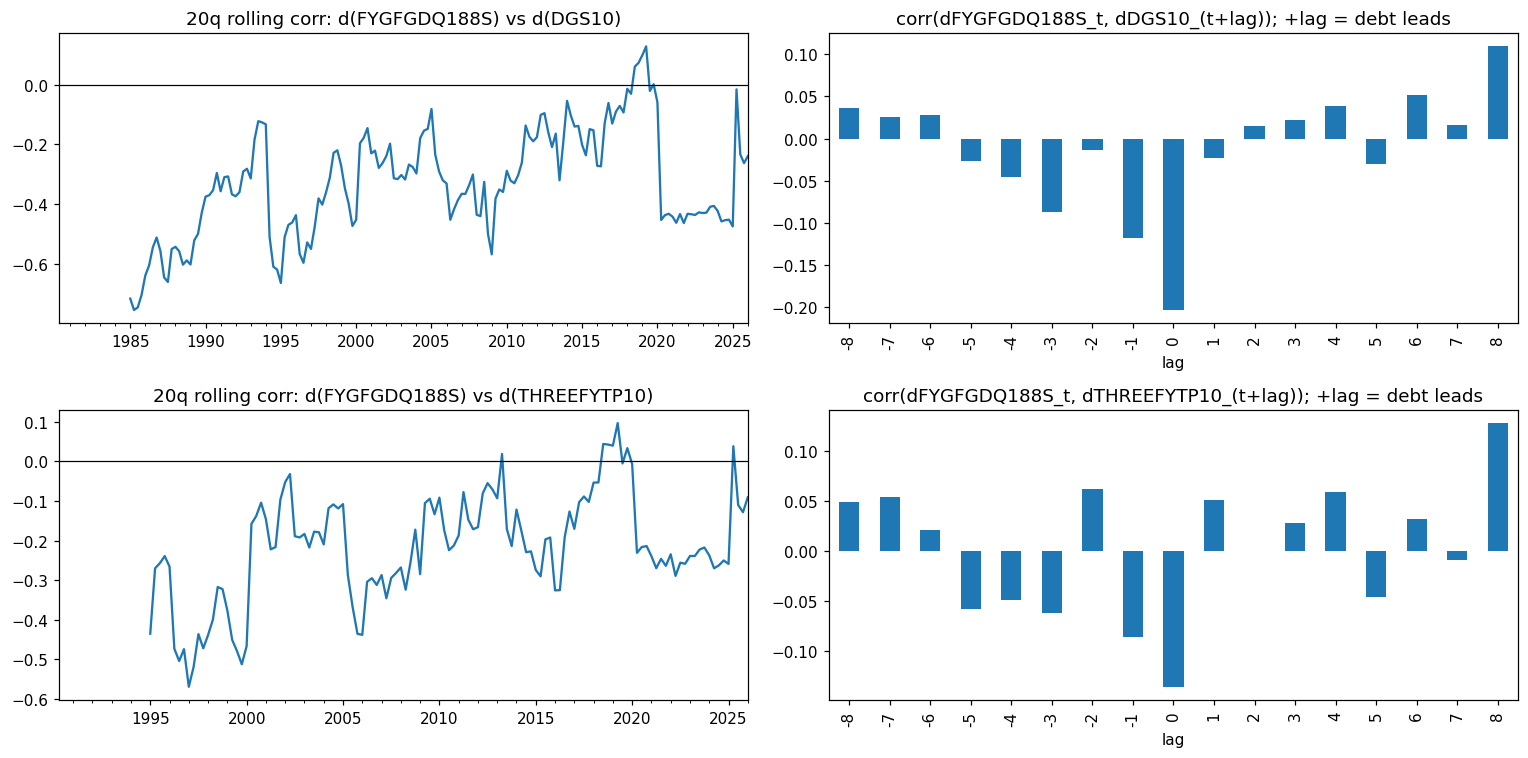

regime timing consistency across the 12 widest pairs, mean adjusted Rand index: 0.109  (near 0: pair-specific; near 1: one market regime)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for row, pair in zip(axes, [("FYGFGDQ188S", "DGS10"), ("FYGFGDQ188S", "THREEFYTP10")]):
    r = an.analyze_pair(*pair, with_granger=False)
    r.rolling.plot(ax=row[0]); row[0].axhline(0, color="k", lw=0.8); row[0].set_title(f"20q rolling corr: d({pair[0]}) vs d({pair[1]})"); row[0].set_xlabel("")
    r.lead_lag.plot.bar(ax=row[1]); row[1].set_title(f"corr(d{pair[0]}_t, d{pair[1]}_(t+lag)); +lag = debt leads")
plt.tight_layout(); plt.show()
det = RegimeDetector(ctx.cfg.correlation)
top = rep[rep.regime_dependent].head(12)
labels = {f"{x.a}|{x.b}": det.label(an.rolling(x.a, x.b).dropna()) for x in top.itertuples()}
cons = det.consistency(labels); off = cons.to_numpy()[~np.eye(len(cons), dtype=bool)]
print(f"regime timing consistency across the 12 widest pairs, mean adjusted Rand index: {np.nanmean(off):.3f}  (near 0: pair-specific; near 1: one market regime)")

## 3.2 Block factors

One factor per block, sign-aligned so that high means expansionary / loose / strong / healthy. The loadings say which
series carry the block; the explained variance says how much of the block is one thing. Sample: the common overlap of all
seven blocks (VIX and the SLOOS series begin 1990).

{"ts": "2026-09-15T17:59:08.741Z", "run_id": null, "pid": 12275, "channel": "sim", "kind": "states.hazard_sign", "level": "WARNING", "beta_estimate": -1.62, "note": "negative slope on the financial factor; hazard channel disabled"}


,n_series,explained_var,n_obs,start
consumer,6,0.393176,147,1990-01-01
corporate,8,0.479032,146,1990-01-01
financial,5,0.582334,146,1990-04-01
fiscal,5,0.410474,144,1990-01-01
labor,3,0.567302,147,1990-01-01
rates,5,0.882982,147,1990-01-01
prices,4,0.767232,147,1990-01-01


,PCE,DSPIC96,PSAVERT,TOTALSL,REVOLSL,UMCSENT,PNFI,CP,BUSLOANS,INDPRO,TCU,NCBDBIQ027S,GDP,GDPC1,NFCI,BAA10Y,VIXCLS,T10Y2Y,DRTSCILM,pb,debt_gdp,int_gdp,receipts_4q,foreign_share,UNRATE,PAYEMS,ICSA,DGS10,DGS3MO,DGS2,DGS30,THREEFYTP10,CPIAUCSL,CPILFESL,PCEPI,MEDCPIM158SFRBCLE
consumer,0.64,-0.47,-0.53,0.79,0.81,0.4,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
corporate,,,,,,,0.71,0.4,-0.47,0.94,0.36,-0.31,0.96,0.95,,,,,,,,,,,,,,,,,,,,,,
financial,,,,,,,,,,,,,,,-0.89,-0.84,-0.88,-0.22,-0.76,,,,,,,,,,,,,,,,,
fiscal,,,,,,,,,,,,,,,,,,,,0.55,-0.85,0.37,0.65,0.69,,,,,,,,,,,,
labor,,,,,,,,,,,,,,,,,,,,,,,,,-0.33,0.93,-0.86,,,,,,,,,
rates,,,,,,,,,,,,,,,,,,,,,,,,,,,,1.0,0.88,0.95,0.97,0.9,,,,
prices,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,0.91,0.88,0.91,0.81


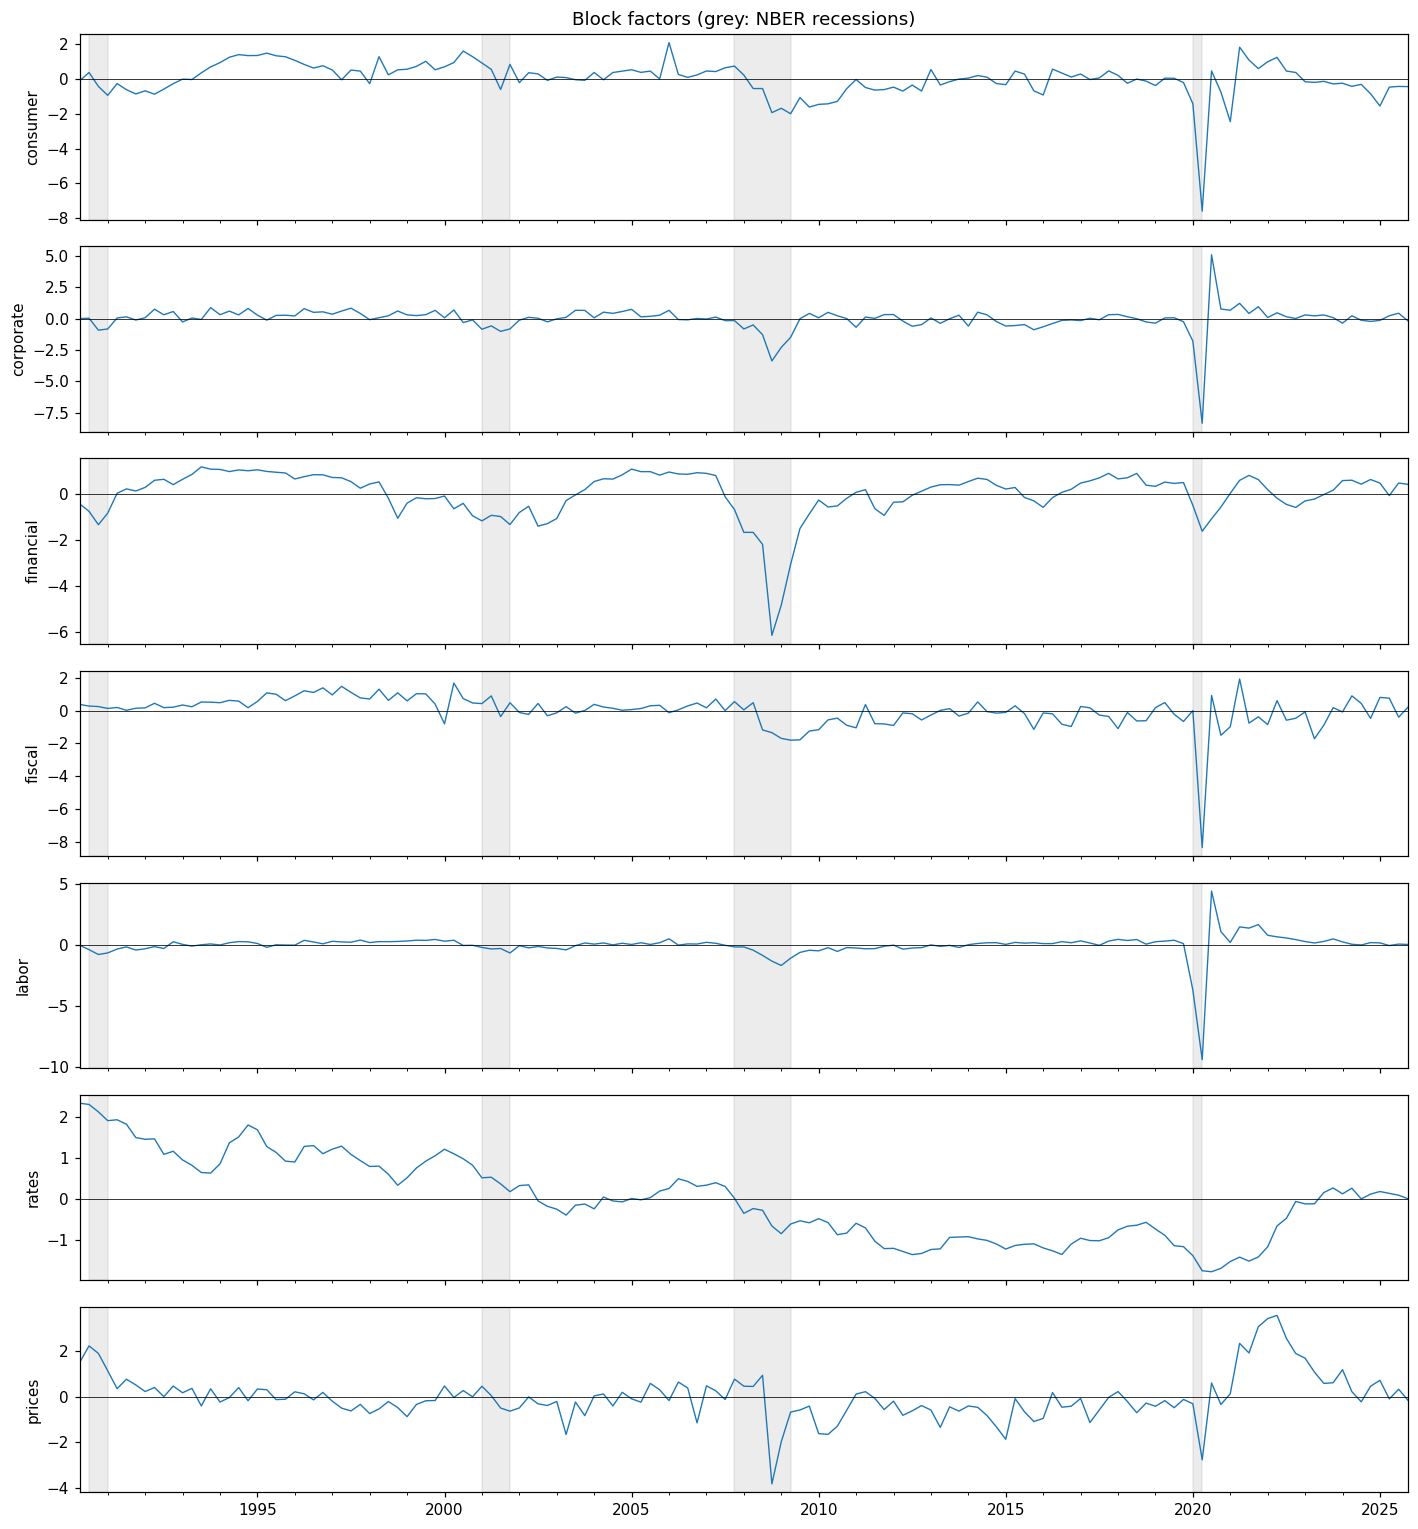

,consumer,corporate,financial,fiscal,labor,rates,prices
consumer,1.00,0.64,0.42,0.75,0.70,0.32,0.40
corporate,0.64,1.00,0.45,0.67,0.89,0.15,0.36
financial,0.42,0.45,1.00,0.37,0.33,0.17,0.26
fiscal,0.75,0.67,0.37,1.00,0.65,0.46,0.27
labor,0.70,0.89,0.33,0.65,1.00,0.04,0.39
rates,0.32,0.15,0.17,0.46,0.04,1.00,0.23
prices,0.40,0.36,0.26,0.27,0.39,0.23,1.00


In [4]:
bf, chain = nb.cached(f"factors_chain_{AS_OF.date()}_{CFG_HASH}", lambda: nb.fit_factors_and_chain(ctx), refresh=FORCE_REFRESH)
display(bf.summary())
load = pd.DataFrame({b: {c: round(float(l), 2) for c, l in zip(f.columns, f.loadings)} for b, f in bf.fits.items()})
display(load.fillna("").T)
F = bf.factors()
fig, axes = plt.subplots(len(F.columns), 1, figsize=(13, 2.0 * len(F.columns)), sharex=True)
for ax, b in zip(axes, F.columns):
    F[b].plot(ax=ax, lw=0.9); ax.axhline(0, color="k", lw=0.5); ax.set_ylabel(b)
    for t0, t1 in [("1990-07-01", "1991-03-01"), ("2001-03-01", "2001-11-01"), ("2007-12-01", "2009-06-01"), ("2020-02-01", "2020-04-01")]:
        ax.axvspan(pd.Timestamp(t0), pd.Timestamp(t1), color="grey", alpha=0.15)
axes[0].set_title("Block factors (grey: NBER recessions)"); plt.tight_layout(); plt.show()
display(F.corr().round(2))

## 3.3 The latent chain

A Gaussian HMM on the factor vector; the state count by BIC over 2-4; a sticky Dirichlet prior on the transition
matrix (sparse regime data, the RateWalk lesson); state 0 is always the weakest by construction. Within each state a
common VAR(1) with state-specific intercepts gives the dynamics; residuals are banked by state for bootstrapping.
The stress hazard is logistic in the financial-conditions factor: the doom-loop channel in state space.

,bic,min_occupancy,admissible
candidate states,,,
2,1936.9,44,True
3,1949.8,17,True
4,1814.4,6,False


chosen: 2 states (lowest BIC among candidates whose every state has >= 8 quarters; factors winsorized at +/-3.5 sd for estimation)
hazard beta (stress entry on the financial factor): 0.000 (unrestricted estimate -1.620; negative estimates disable the channel)   max eigenvalue of A: 0.941


,to 0,to 1
from 0,0.924,0.076
from 1,0.035,0.965


,consumer,corporate,financial,fiscal,labor,rates,prices
state 0,-0.33,-0.18,-0.81,-0.45,-0.15,-0.58,0.10
state 1,0.19,0.10,0.39,0.25,0.11,0.24,-0.07


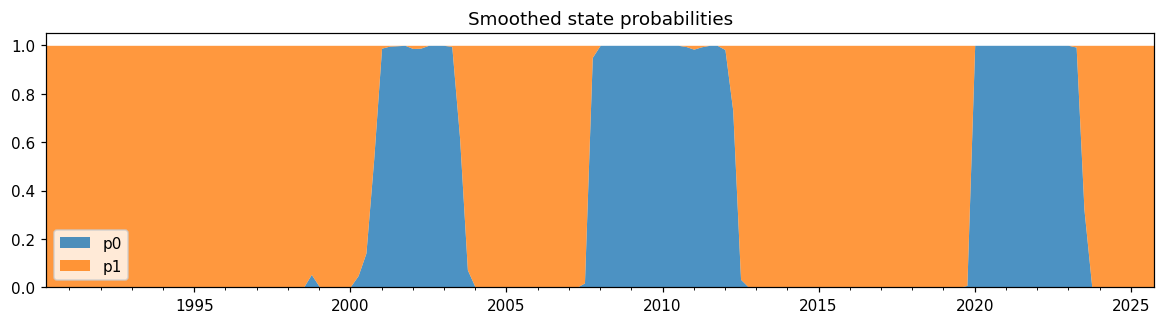

state counts: [44, 99]
quarters in state 0: ['2001-01', '2001-04', '2001-07', '2001-10', '2002-01', '2002-04', '2002-07', '2002-10', '2003-01', '2003-04', '2003-07', '2007-10', '2008-01', '2008-04', '2008-07', '2008-10', '2009-01', '2009-04', '2009-07', '2009-10', '2010-01', '2010-04', '2010-07', '2010-10', '2011-01', '2011-04', '2011-07', '2011-10', '2012-01', '2012-04', '2020-01', '2020-04', '2020-07', '2020-10', '2021-01', '2021-04', '2021-07', '2021-10', '2022-01', '2022-04', '2022-07', '2022-10', '2023-01', '2023-04']


In [5]:
display(pd.DataFrame(chain.selection).T.rename_axis("candidate states"))
print(f"chosen: {chain.k} states (lowest BIC among candidates whose every state has >= {chain.min_state_occupancy} quarters; factors winsorized at +/-{chain.winsor_sd} sd for estimation)")
print(f"hazard beta (stress entry on the financial factor): {chain.hazard_beta:.3f} (unrestricted estimate {chain.hazard_beta_raw:.3f}; negative estimates disable the channel)   max eigenvalue of A: {np.abs(np.linalg.eigvals(chain.A)).max():.3f}")
display(pd.DataFrame(chain.P, index=[f"from {s}" for s in range(chain.k)], columns=[f"to {s}" for s in range(chain.k)]).round(3))
display(pd.DataFrame(chain.means, columns=chain.blocks, index=[f"state {s}" for s in range(chain.k)]).round(2))
fig, ax = plt.subplots(figsize=(13, 3))
chain.posterior.plot.area(ax=ax, linewidth=0, alpha=0.8); ax.set_title("Smoothed state probabilities"); ax.set_xlabel(""); plt.show()
print("state counts:", np.bincount(chain.states, minlength=chain.k).tolist())
print("quarters in state 0:", [d.strftime("%Y-%m") for d in chain.states[chain.states == 0].index])

## 3.4 Why not a normal distribution

The residuals the simulator bootstraps from are not Gaussian: skewness and excess kurtosis by state, against zero for
a normal. This is the empirical basis for drawing from history instead of from a fitted family.

skew       excess_kurtosis      
state         0     1               0     1
block                                      
consumer   0.84  0.45            3.17  1.86
corporate  0.86  0.07            6.95 -0.80
financial -0.50 -0.96            0.51  1.84
fiscal     0.88 -0.14            2.48  0.02
labor      0.67  0.23            9.63 -0.20
prices    -0.98 -0.05            4.43  0.27
rates      0.09  0.58           -0.56  0.81

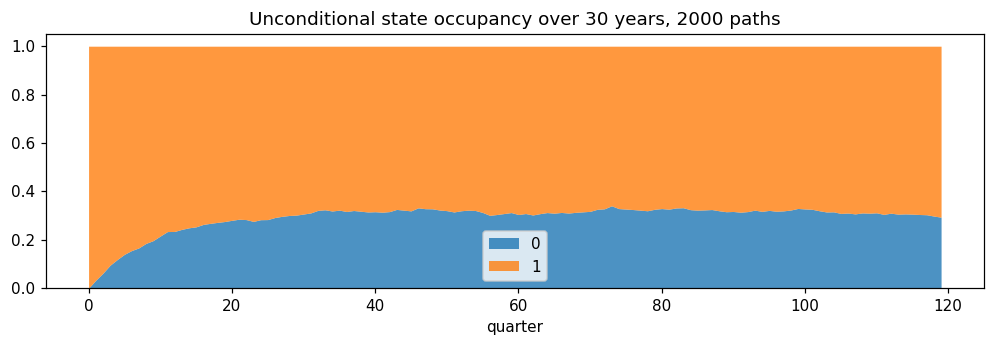

In [6]:
from scipy import stats
rows = []
for s, bank in chain.resid_bank.items():
    for j, b in enumerate(chain.blocks):
        rows.append({"state": s, "block": b, "n": len(bank), "skew": stats.skew(bank[:, j]), "excess_kurtosis": stats.kurtosis(bank[:, j])})
display(pd.DataFrame(rows).pivot(index="block", columns="state", values=["skew", "excess_kurtosis"]).round(2))
draws = chain.draw(2000, 120, np.random.default_rng(0))
sim = chain.simulate(2000, 120, draws, bf.last_factors(), chain.initial_state_probs())
occ = chain.occupancy(sim["S"])
ax = occ.plot.area(figsize=(11, 3), linewidth=0, alpha=0.8); ax.set_title("Unconditional state occupancy over 30 years, 2000 paths"); ax.set_xlabel("quarter"); plt.show()